In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
claims = pd.read_csv('cleaned_claims.csv')
claims

,member_number,days_since_earliest_dt,c_allowed,C_UTIL_CT,Med_Cost_Category,PRI_DIAG_CD,ICD10_simple,DIAG_DESC,DIAG_CD_001,DIAG_CD_002,...,DIAG_001_DIAG_DESC,DIAG_002_DIAG_DESC,DIAG_003_DIAG_DESC,HCPCS,PROC_DESC,NDC_CD,DRUG_NM,ROUTE DESCRIPTION,STRENGTH DESCRIPTION,provider_number
0,A001,-364,18.500000,1.0,Prof PCP Procedures,J431,J43,Panlobular emphysema,NaN,NaN,...,NaN,NaN,NaN,94727,PULM FUNCTION TEST BY GAS,NaN,NaN,NaN,NaN,NaN
1,A001,-364,20.000000,1.0,Prof PCP Procedures,J431,J43,Panlobular emphysema,NaN,NaN,...,NaN,NaN,NaN,94060,EVALUATION OF WHEEZING,NaN,NaN,NaN,NaN,NaN
2,A001,-364,458.120000,1.0,OP Other,J431,J43,Panlobular emphysema,NaN,NaN,...,NaN,NaN,NaN,94060,EVALUATION OF WHEEZING,NaN,NaN,NaN,NaN,2236.0
3,A001,-364,0.000000,0.0,OP Other,J431,J43,Panlobular emphysema,NaN,NaN,...,NaN,NaN,NaN,94726,PULM FUNCT TST PLETHYSMOGRAP,NaN,NaN,NaN,NaN,2236.0
4,A001,-364,0.000000,0.0,OP Other,J431,J43,Panlobular emphysema,NaN,NaN,...,NaN,NaN,NaN,94729,CO/MEMBANE DIFFUSE CAPACITY,NaN,NaN,NaN,NaN,2236.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2517382,D660,65,17.510413,0.0,OP Path/Lab,C50411,C50,Malig neoplm of upper-outer quadrant of right ...,Z170,E1165,...,Estrogen receptor positive status [ER+],Type 2 diabetes mellitus with hyperglycemia,Long term (current) use of insulin,83036,GLYCOSYLATED HEMOGLOBIN TEST,NaN,NaN,NaN,NaN,8094.0
2517383,D660,65,27.194525,0.0,OP Path/Lab,C50411,C50,Malig neoplm of upper-outer quadrant of right ...,Z170,E1165,...,Estrogen receptor positive status [ER+],Type 2 diabetes mellitus with hyperglycemia,Long term (current) use of insulin,82607,VITAMIN B-12,NaN,NaN,NaN,NaN,8094.0
2517384,D660,65,24.140880,0.0,OP Path/Lab,C50411,C50,Malig neoplm of upper-outer quadrant of right ...,Z170,E1165,...,Estrogen receptor positive status [ER+],Type 2 diabetes mellitus with hyperglycemia,Long term (current) use of insulin,80061,LIPID PANEL,NaN,NaN,NaN,NaN,8094.0
2517385,D660,65,14.008330,0.0,OP Path/Lab,C50411,C50,Malig neoplm of upper-outer quadrant of right ...,Z170,E1165,...,Estrogen receptor positive status [ER+],Type 2 diabetes mellitus with hyperglycemia,Long term (current) use of insulin,85025,COMPLETE CBC W/AUTO DIFF WBC,NaN,NaN,NaN,NaN,8094.0


In [4]:
claims['days_since_earliest_dt'].describe().astype(int)

count    2517387
mean         704
std          822
min         -366
25%           91
50%          383
75%         1127
max         3819
Name: days_since_earliest_dt, dtype: int64

In [5]:
claims['days_since_earliest_dt'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50     383.0
0.75    1127.0
0.90    1986.0
0.95    2471.0
0.99    3179.0
Name: days_since_earliest_dt, dtype: float64

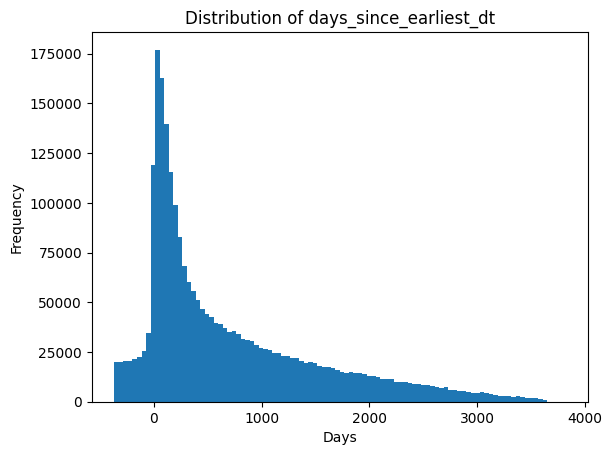

In [7]:
plt.hist(claims['days_since_earliest_dt'], bins=100)
plt.title('Distribution of days_since_earliest_dt')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

In [9]:
# claims per member
claims_per_member = claims.groupby('member_number').size()

claims_per_member.describe()

count    3657.000000
mean      688.374897
std       516.955787
min         3.000000
25%       321.000000
50%       577.000000
75%       943.000000
max      4371.000000
dtype: float64

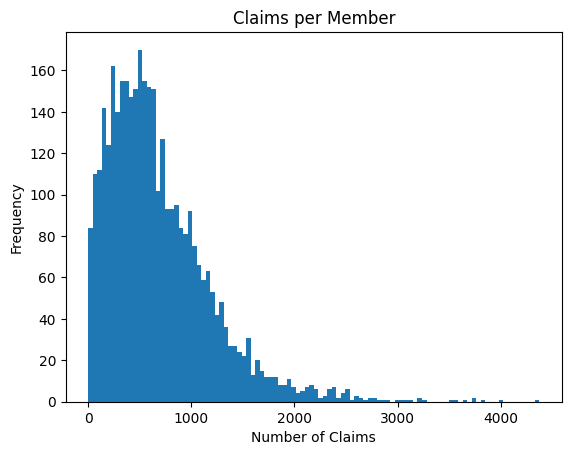

In [10]:
plt.hist(claims_per_member, bins=100)
plt.title('Claims per Member')
plt.xlabel('Number of Claims')
plt.ylabel('Frequency')
plt.show()

In [13]:
claims['c_allowed'].describe().astype(int)

count    2517387
mean         269
std         1883
min            0
25%            3
50%           23
75%          106
max       569337
Name: c_allowed, dtype: int64

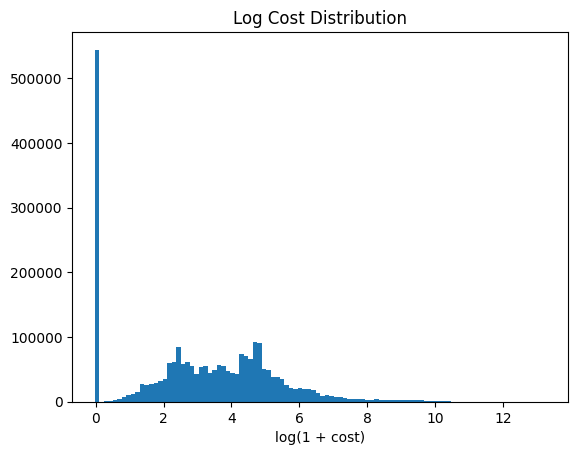

In [15]:
plt.hist(np.log1p(claims['c_allowed']), bins=100)
plt.title('Log Cost Distribution')
plt.xlabel('log(1 + cost)')
plt.show()

In [16]:
daily_cost = (
    claims
    .groupby('days_since_earliest_dt')['c_allowed']
    .mean()
    .reset_index()
)

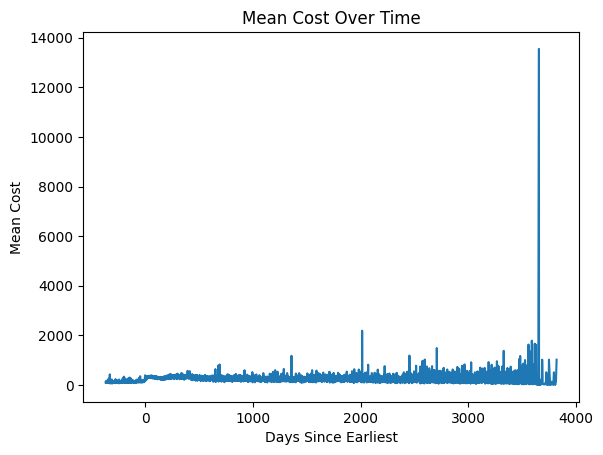

In [17]:
plt.plot(daily_cost['days_since_earliest_dt'],
         daily_cost['c_allowed'])
plt.title('Mean Cost Over Time')
plt.xlabel('Days Since Earliest')
plt.ylabel('Mean Cost')
plt.show()

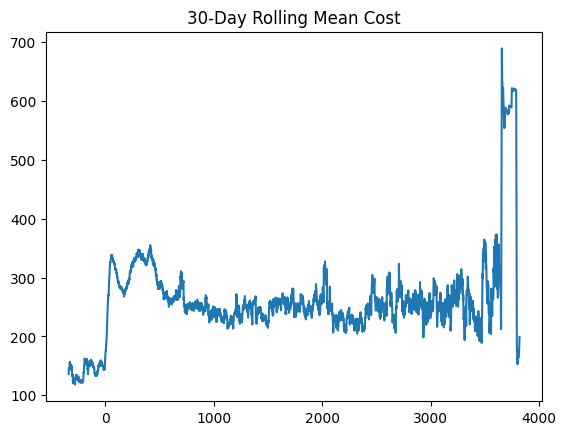

In [18]:
daily_cost['rolling_mean'] = daily_cost['c_allowed'].rolling(30).mean()

plt.plot(daily_cost['days_since_earliest_dt'],
         daily_cost['rolling_mean'])
plt.title('30-Day Rolling Mean Cost')
plt.show()

In [20]:
total_cost_per_member = (
    claims.groupby('member_number')['c_allowed']
    .sum()
)

total_cost_per_member.describe().astype(int)

count       3657
mean      185295
std       266305
min            0
25%        53610
50%       105771
75%       207329
max      3780082
Name: c_allowed, dtype: int64

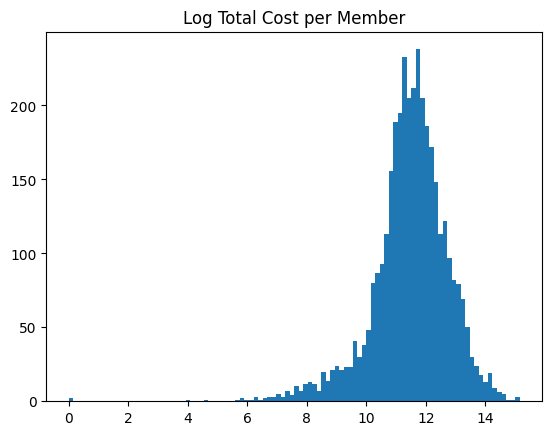

In [21]:
plt.hist(np.log1p(total_cost_per_member), bins=100)
plt.title('Log Total Cost per Member')
plt.show()

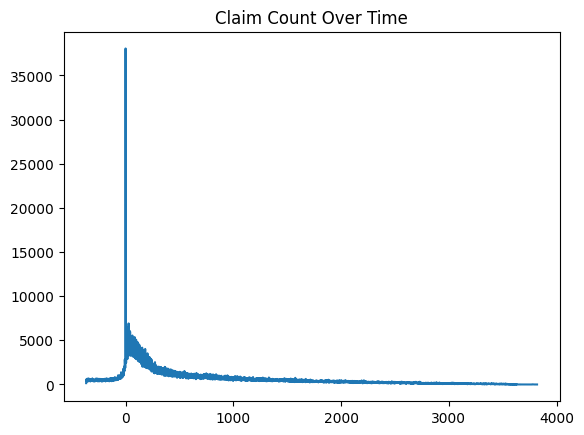

In [22]:
daily_claims = (
    claims.groupby('days_since_earliest_dt')
    .size()
    .reset_index(name='claim_count')
)

plt.plot(daily_claims['days_since_earliest_dt'],
         daily_claims['claim_count'])
plt.title('Claim Count Over Time')
plt.show()